In [56]:
from pathlib import Path
import json
import sys
import os

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

backend = Path.cwd().parents[1]
sys.path.insert(0, str(backend))

from computerVision.train_model import build_model
from computerVision.basemodels import load_config

ROOT = Path.cwd()
while not (ROOT / "computerVision").exists():
    ROOT = ROOT.parent

TEST_DIR = ROOT / "computerVision" / "images" / "test_images"
LABELS_JSON = str(TEST_DIR / "labels.json")
MODEL_PATH = str(ROOT / "computerVision" / "models" / "test_3.pth")
CONFIG_PATH = str(ROOT / "computerVision" / "models" / "test_3.json")

config = load_config(CONFIG_PATH)
classes = config.meta.classes
num_classes = len(classes)
device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.7

print(f"Using device: {device}")
print(f"Test images folder: {TEST_DIR}")
print(f"Model config: {CONFIG_PATH}")
print(f"Model weights: {MODEL_PATH}")


Using device: cuda
Test images folder: c:\Users\Nelly\Documents\Programmieren\kuehlscharnkKI\backend\computerVision\images\test_images
Model config: c:\Users\Nelly\Documents\Programmieren\kuehlscharnkKI\backend\computerVision\models\test_3.json
Model weights: c:\Users\Nelly\Documents\Programmieren\kuehlscharnkKI\backend\computerVision\models\test_3.pth


In [57]:
def load_labels(labels_path):
    with open(labels_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    labels_by_image = {}
    for entry in raw:
        img_name = entry["image"]
        if img_name.endswith(".jpg"):
            img_name = img_name[:-4]
        labels_by_image[img_name] = entry.get("annotations", [])
    return labels_by_image


def predict_image(model, image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    image = cv2.imread(str(image_path))
    if image is None:
        return None, None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    tensor = transform(pil_image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    preds = (probs >= THRESHOLD).astype(int)
    return preds, probs


labels_by_image = load_labels(LABELS_JSON)
image_paths = sorted([p for p in TEST_DIR.iterdir() if p.is_file() and p.suffix.lower() == ".jpg"])

print(f"Loaded {len(labels_by_image)} label entries and {len(image_paths)} images")


Loaded 65 label entries and 65 images


In [58]:
model = build_model(num_classes=num_classes, model=config.settings.model)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

all_true = []
all_pred = []
processed_images = []

for image_path in image_paths:
    image_name = image_path.stem
    if image_name not in labels_by_image:
        continue

    true_labels = labels_by_image[image_name]
    pred, probs = predict_image(model, image_path, device)
    if pred is None:
        continue

    true_vector = np.array([1 if cls in true_labels else 0 for cls in classes], dtype=int)
    pred_vector = pred.astype(int)

    all_true.append(true_vector)
    all_pred.append(pred_vector)
    processed_images.append(image_path.name)

all_true = np.array(all_true, dtype=int)
all_pred = np.array(all_pred, dtype=int)

print(f"Processed {len(processed_images)} / {len(image_paths)} images")


Processed 65 / 65 images


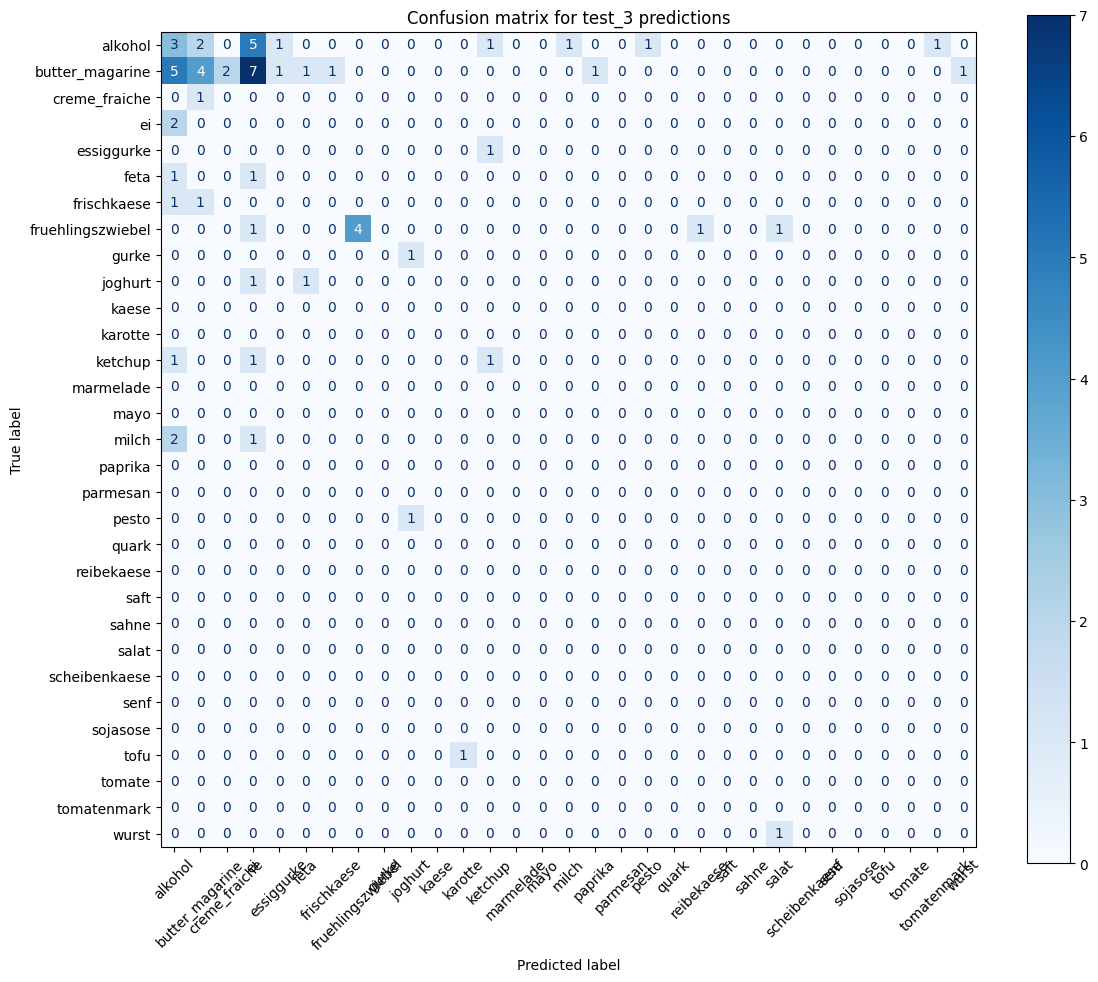

alkohol              TP=1 FP=8 FN=11
butter_magarine      TP=6 FP=4 FN=21
creme_fraiche        TP=2 FP=2 FN=4
ei                   TP=8 FP=16 FN=9
essiggurke           TP=4 FP=5 FN=2
feta                 TP=4 FP=5 FN=5
frischkaese          TP=1 FP=3 FN=12
fruehlingszwiebel    TP=4 FP=1 FN=8
gurke                TP=0 FP=5 FN=6
joghurt              TP=8 FP=7 FN=13
kaese                TP=0 FP=4 FN=6
karotte              TP=2 FP=1 FN=3
ketchup              TP=2 FP=5 FN=10
marmelade            TP=4 FP=7 FN=1
mayo                 TP=1 FP=3 FN=5
milch                TP=6 FP=11 FN=12
paprika              TP=4 FP=11 FN=5
parmesan             TP=0 FP=0 FN=2
pesto                TP=2 FP=5 FN=10
quark                TP=3 FP=1 FN=7
reibekaese           TP=2 FP=9 FN=6
saft                 TP=2 FP=6 FN=3
sahne                TP=3 FP=8 FN=7
salat                TP=1 FP=4 FN=3
scheibenkaese        TP=1 FP=9 FN=7
senf                 TP=0 FP=7 FN=4
sojasose             TP=0 FP=4 FN=6
tofu              

In [59]:
cm = confusion_matrix(all_true.argmax(axis=1), all_pred.argmax(axis=1), labels=np.arange(num_classes))

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion matrix for test_3 predictions")
plt.tight_layout()
plt.show()

# Also print a simple per-class summary
for i, cls in enumerate(classes):
    tp = int(((all_true[:, i] == 1) & (all_pred[:, i] == 1)).sum())
    fp = int(((all_true[:, i] == 0) & (all_pred[:, i] == 1)).sum())
    fn = int(((all_true[:, i] == 1) & (all_pred[:, i] == 0)).sum())
    print(f"{cls:<20} TP={tp} FP={fp} FN={fn}")


Image: 1BeyZmwOkxVxj6-3TR3VV4_YTNphR0Piw.jpg | predicted classes (>= 0.7): ['pesto', 'tomatenmark']


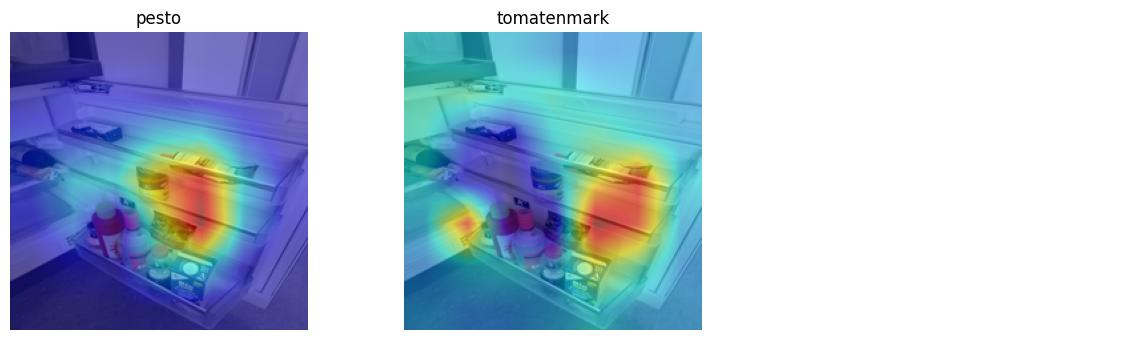

In [67]:
def show_gradcam_for_image(model, image_path, class_indices, device, target_layer=None):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    pil_resized = pil_image.resize((224, 224))
    tensor = transform(pil_image).unsqueeze(0).to(device)

    if target_layer is None:
        target_layer = model.features[-1]

    cam = GradCAM(model=model, target_layers=[target_layer])

    img_display = np.array(pil_resized) / 255.0
    
    # Dynamically calculate grid for heatmaps only (3 columns)
    n_cols = 3
    n_rows = int(np.ceil(len(class_indices) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # Place all heatmaps
    for row in range(n_rows):
        for col in range(n_cols):
            idx = row * n_cols + col
            ax = axes[row, col]
            
            if idx < len(class_indices):
                class_idx = class_indices[idx]
                targets = [ClassifierOutputTarget(class_idx)]
                grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]
                visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
                ax.imshow(visualization)
                ax.set_title(classes[class_idx])
            
            ax.axis("off")

    plt.tight_layout()
    plt.show()


sample_image = image_paths[17]
pred, probs = predict_image(model, sample_image, device)
if pred is not None:
    predicted_indices = np.where(probs >= THRESHOLD)[0]
    print(f"Image: {sample_image.name} | predicted classes (>= {THRESHOLD}): {[classes[i] for i in predicted_indices]}")
    show_gradcam_for_image(model, sample_image, predicted_indices.tolist(), device)